# 📦 중국 C-commerce 패션 카테고리 성장 분석

**프로젝트 기간**: 2024.11 ~ 2024.12  
**분석 도구**: Python (NumPy, Pandas, Plotly, Selenium)

---

## 🔍 분석 배경

2022년 이후 테무(Temu), 알리익스프레스(AliExpress) 등 중국 C-commerce 플랫폼이 국내 이커머스 시장에 급속도로 진입했다.  
배송 불안정, 품질 이슈, 개인정보 우려 등 부정적 인식이 공존함에도 거래액은 꾸준히 증가했다.  
특히 **패션·의류 카테고리**는 가전, 화장품 등 다른 품목 대비 두드러진 성장을 보였다.

## 🔬 분석 가설

> 패션 카테고리는 **가격·관세·소비자 심리**라는 구조적 요인으로 중국 직구 수용이 상대적으로 크며,  
> **광고와 콘텐츠 노출**이 집중되어 부정적 인식에도 불구하고 구매가 지속된다.

## 📋 분석 목차

1. 환경 설정 및 데이터 로드  
2. 전체 해외 직구 현황 (지역별)  
3. 중국 직구 성장 추이  
4. 카테고리별 성장 지수 분석  
5. 국내 온라인 vs 중국 직구 패션 비교  
6. 구조적 요인 분석 (가격·관세·소비자 심리)  
7. 결론 및 시사점

---

## 1. 환경 설정 및 데이터 로드

**데이터 출처**
- `china_data.csv`: 관세청 해외직구 국가·품목별 통계 + KOSIS 온라인쇼핑 해외직구 거래액
- `korea_data.csv`: KOSIS 온라인쇼핑 국내 상품군별 거래액

분석 기간: 2021Q1 ~ 2024Q4 (총 16분기)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# 중국 직구 데이터 로드
df = pd.read_csv('china_data.csv', encoding='cp949')
print(f'데이터 shape: {df.shape}')
df.head(3)

데이터 shape: (323, 24)


,지역별(1),지역별(2),지역별(3),상품군별(1),상품군별(2),2021.1/4,2021.2/4,2021.3/4,2021.4/4,2022.1/4,...,2023.2/4,2023.3/4,2023.4/4,2024.1/4,2024.2/4,2024.3/4,2024.4/4,2025.1/4,2025.2/4,2025.3/4 p)
0,합계,소계,소계,합계,소계,1193768.0,1223034.0,1248833.0,1591767.0,1433886.0,...,1651862.0,1643306.0,1988739.0,1862874.0,2060723.0,1943120.0,2219544.0,1955097.0,2176199.0,2122375.0
1,합계,소계,소계,컴퓨터 및 주변기기,소계,18233.0,14265.0,13394.0,21322.0,23235.0,...,26932.0,36266.0,48389.0,52215.0,48873.0,41686.0,49771.0,48930.0,43202.0,54338.0
2,합계,소계,소계,가전·전자·통신기기,소계,103582.0,77969.0,71078.0,114809.0,83434.0,...,89773.0,101669.0,138244.0,126577.0,127771.0,123528.0,139082.0,120567.0,134623.0,140729.0


---

## 2. 전체 해외 직구 현황 (지역별)

2024년 기준 지역별 해외직구 비중을 파악한다.  
아시아 내에서 중국이 차지하는 비중을 확인해 C-commerce의 국내 시장 지배력을 파악한다.

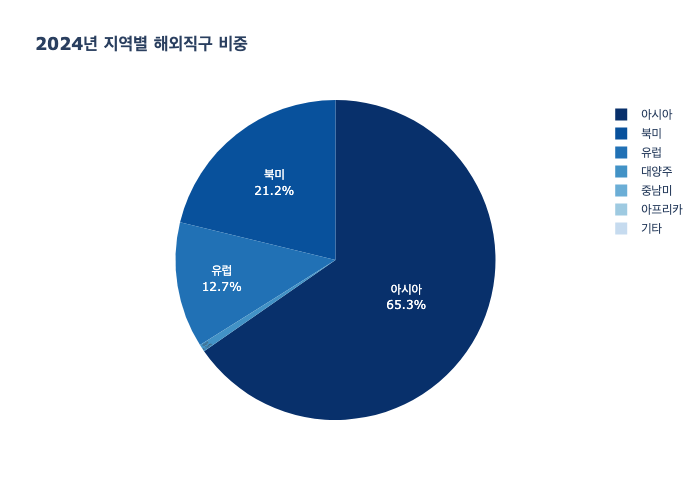

In [3]:
# 지역별 2024년 합계 계산
df_continent = df[
    (df['지역별(1)'] != '합계') & 
    (df['상품군별(1)'] == '합계')
].copy()

quarter_cols_2024 = [c for c in df.columns if c.startswith('2024')]
df_continent_2024 = df_continent[['지역별(1)'] + quarter_cols_2024].copy()
df_continent_2024_group = df_continent_2024.groupby('지역별(1)').sum(numeric_only=True)
df_continent_2024_group['2024'] = df_continent_2024_group.sum(axis=1)

df_plot = df_continent_2024_group.reset_index()

fig = px.pie(
    df_plot,
    values='2024',
    names='지역별(1)',
    title='<b>2024년 지역별 해외직구 비중</b>',
    color_discrete_sequence=px.colors.sequential.Blues_r
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show(renderer='png')

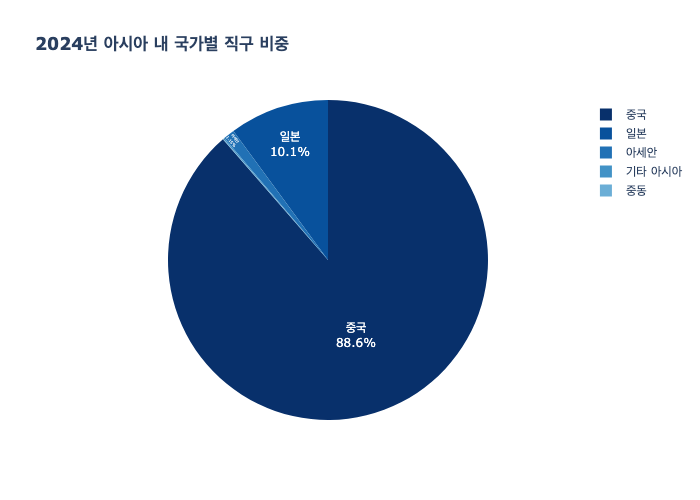

In [4]:
# 아시아 내 국가별 비중 (2024년)
df_asia = df[
    (df['지역별(1)'] == '아시아') & 
    (df['지역별(2)'] != '소계') & 
    (df['상품군별(1)'] == '합계')
].copy()

df_asia_2024 = df_asia[['지역별(2)'] + quarter_cols_2024].copy()
df_asia_2024_group = df_asia_2024.groupby('지역별(2)').sum(numeric_only=True)
df_asia_2024_group['2024'] = df_asia_2024_group.sum(axis=1)

df_plot = df_asia_2024_group.reset_index()

fig = px.pie(
    df_plot,
    values='2024',
    names='지역별(2)',
    title='<b>2024년 아시아 내 국가별 직구 비중</b>',
    color_discrete_sequence=px.colors.sequential.Blues_r
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show(renderer='png')

---

## 3. 중국 직구 성장 추이

2021Q1부터 분기별 중국 직구 거래액 추이와 성장지수를 분석한다.  
**2023년 테무 한국 론칭(23.07)**, 알리익스프레스 본격 사업 확장(23년)과 맞물린 성장 가속을 확인한다.

In [5]:
# 중국 직구 데이터 전처리
china_df = df[df['지역별(2)'] == '중국'].copy()
china_df = china_df.set_index('상품군별(1)')
china = china_df.T
china = china.drop(china.index[0:4])  # 헤더 행 제거
china = china.reset_index().rename(columns={'index': '분기'})

# 분기 형식 변환 (2021.1/4 → 2021Q1)
china['분기'] = china['분기'].astype(str).str.replace(r'\.(\d)/4', r'Q\1', regex=True)
china['분기'] = china['분기'].str.replace(' p)', '', regex=False)

# 결측치 처리 및 자료형 변환
china = china.fillna(0)
china = china.infer_objects(copy=False)
china.loc[:, '합계'] = china.loc[:, '합계'].astype(float)

# 중복 열 이름 수정
new_cols = list(china.columns)
new_cols[3] = '가전·전자·통신기기'
new_cols[4] = '가전·전자_소분류'
new_cols[5] = '통신기기_소분류'
china.columns = new_cols

print(f'분석 기간: {china["분기"].iloc[0]} ~ {china["분기"].iloc[-1]} (총 {len(china)}분기)')
china[['분기', '합계', '의류 및 패션 관련 상품']].head(5)

분석 기간: 2021Q1 ~ 2025Q3 (총 19분기)


,분기,합계,의류 및 패션 관련 상품
0,2021Q1,283120.0,96702.0
1,2021Q2,333570.0,163841.0
2,2021Q3,350357.0,191168.0
3,2021Q4,465622.0,265834.0
4,2022Q1,407120.0,230650.0


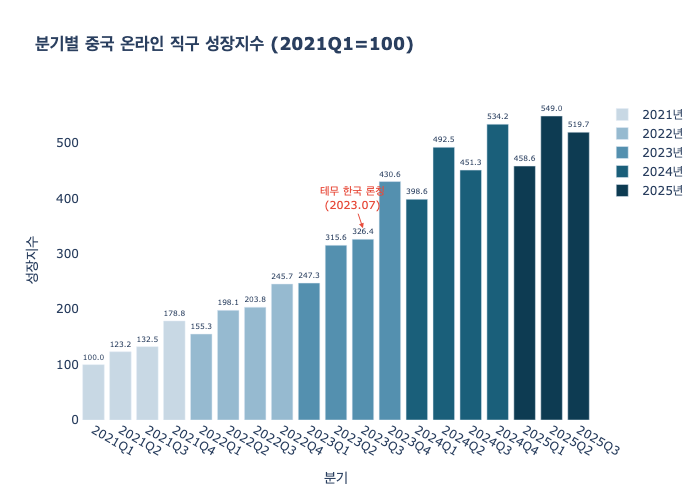

In [6]:
# 분기별 중국 직구 성장지수 (2021Q1 = 100)
categories = [
    '컴퓨터 및 주변기기', '가전·전자·통신기기',
    '사무·문구', '의류 및 패션 관련 상품', '스포츠·레저용품',
    '화장품', '아동·유아용품', '생활·자동차용품'
]

df_plot = china.copy()
df_plot[categories] = df_plot[categories].apply(pd.to_numeric, errors='coerce')
df_plot['총구매액'] = df_plot[categories].sum(axis=1)

first_val = df_plot['총구매액'].iloc[0]
df_plot['성장지수'] = (df_plot['총구매액'] / first_val * 100).round(1)
df_plot['연도'] = df_plot['분기'].str[:4]

colors = {'2021': '#C8D8E4', '2022': '#96BAD0', '2023': '#5490AF', '2024': '#1A5F7A', '2025': '#0D3B52'}

fig = go.Figure()
for year, color in colors.items():
    mask = df_plot['연도'] == year
    if mask.any():
        fig.add_trace(go.Bar(
            x=df_plot[mask]['분기'],
            y=df_plot[mask]['성장지수'],
            name=f'{year}년',
            marker_color=color,
            text=df_plot[mask]['성장지수'].astype(str),
            textposition='outside'
        ))

fig.update_layout(
    title='<b>분기별 중국 온라인 직구 성장지수 (2021Q1=100)</b>',
    xaxis_title='분기',
    yaxis_title='성장지수',
    barmode='group',
    plot_bgcolor='white',
    height=500
)

# 테무 론칭 시점 어노테이션
temu_idx = df_plot[df_plot['분기'] == '2023Q3'].index
if len(temu_idx) > 0:
    temu_y = df_plot.loc[temu_idx[0], '성장지수']
    fig.add_annotation(
        x='2023Q3', y=temu_y + 20,
        text='테무 한국 론칭<br>(2023.07)',
        showarrow=True, arrowhead=2,
        arrowcolor='#E74C3C',
        font=dict(color='#E74C3C', size=11)
    )

fig.show(renderer='png')

---

## 4. 카테고리별 성장 지수 분석

중국 직구 내 카테고리별 YoY 성장률과 성장지수를 비교해  
**패션·의류 카테고리가 다른 품목 대비 구조적으로 급성장한 패턴**을 파악한다.

In [7]:
# 카테고리별 YoY 성장률 계산
china_long = china.melt(
    id_vars=['분기'],
    value_vars=categories,
    var_name='카테고리',
    value_name='거래액'
)

china_long['거래액'] = pd.to_numeric(china_long['거래액'], errors='coerce')
china_long = china_long.sort_values(['카테고리', '분기']).reset_index(drop=True)
china_long['거래액_1년전'] = china_long.groupby('카테고리')['거래액'].shift(4)
china_long['YoY성장률'] = (
    ((china_long['거래액'] / china_long['거래액_1년전']) - 1) * 100
).round(2)

print('카테고리별 평균 YoY 성장률')
avg_growth = china_long.groupby('카테고리')['YoY성장률'].mean().sort_values(ascending=False)
print(avg_growth.to_string())

카테고리별 평균 YoY 성장률
카테고리
컴퓨터 및 주변기기       78.328667
생활·자동차용품         73.586000
사무·문구            57.294000
화장품              49.262667
의류 및 패션 관련 상품    48.416667
스포츠·레저용품         38.604667
아동·유아용품          37.495333
가전·전자·통신기기       35.570000


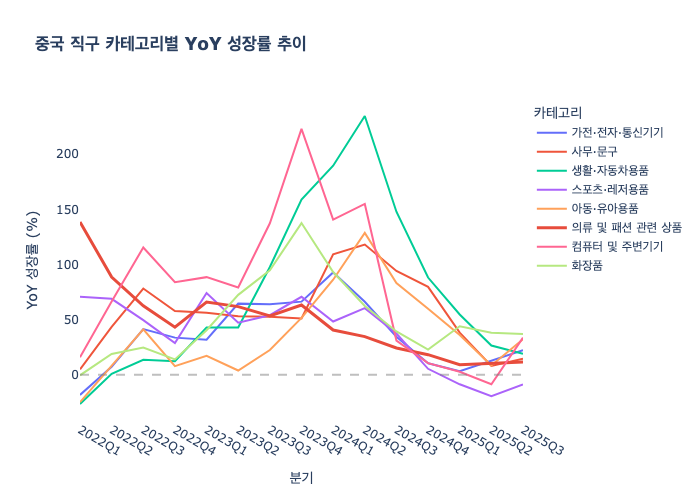

In [8]:
# 카테고리별 YoY 성장률 추이 (선 그래프)
df_growth = china_long.dropna(subset=['YoY성장률'])

fig = px.line(
    df_growth,
    x='분기',
    y='YoY성장률',
    color='카테고리',
    title='<b>중국 직구 카테고리별 YoY 성장률 추이</b>',
    labels={'YoY성장률': 'YoY 성장률 (%)', '분기': '분기'},
    height=500
)

# 의류·패션 라인 강조
for trace in fig.data:
    if '의류' in trace.name:
        trace.line.width = 3
        trace.line.color = '#E74C3C'

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(plot_bgcolor='white')
fig.show(renderer='png')

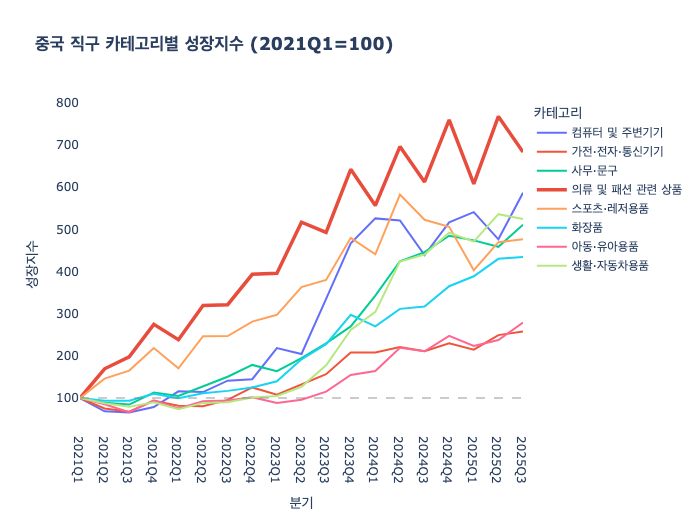

In [9]:
# 카테고리별 성장지수 (2021Q1 = 100 기준)
df_indexed = china[['분기'] + categories].copy()
df_indexed[categories] = df_indexed[categories].apply(pd.to_numeric, errors='coerce')

base_row = df_indexed[df_indexed['분기'] == '2021Q1']
for cat in categories:
    base_val = base_row[cat].values[0]
    if base_val != 0:
        df_indexed[cat] = (df_indexed[cat] / base_val * 100).round(1)

df_indexed_long = df_indexed.melt(
    id_vars=['분기'],
    value_vars=categories,
    var_name='카테고리',
    value_name='성장지수'
)

fig = px.line(
    df_indexed_long,
    x='분기',
    y='성장지수',
    color='카테고리',
    title='<b>중국 직구 카테고리별 성장지수 (2021Q1=100)</b>',
    height=520
)

for trace in fig.data:
    if '의류' in trace.name:
        trace.line.width = 3.5
        trace.line.color = '#E74C3C'

fig.add_hline(y=100, line_dash='dash', line_color='gray', opacity=0.4)
fig.update_layout(plot_bgcolor='white')
fig.show(renderer='png')

In [10]:
# 의류·패션 카테고리 성장 배율 확인
target_item = '의류 및 패션 관련 상품'
latest_q = df_indexed['분기'].iloc[-1]

base_idx  = df_indexed[df_indexed['분기'] == '2021Q2'][target_item].values[0]
latest_idx = df_indexed[df_indexed['분기'] == latest_q][target_item].values[0]

print(f'의류·패션 카테고리 성장지수 비교')
print(f'  2021Q2: {base_idx:.1f}')
print(f'  {latest_q}: {latest_idx:.1f}')
print(f'  성장 배율: {latest_idx / base_idx:.1f}배')

의류·패션 카테고리 성장지수 비교
  2021Q2: 169.4
  2025Q3: 683.6
  성장 배율: 4.0배


---

## 5. 국내 온라인 vs 중국 직구 패션 비교

국내 온라인 쇼핑 패션 거래액과 중국 직구 패션 거래액을 비교해  
**C-commerce 플랫폼 진입이 국내 패션 시장에 미친 영향**을 분석한다.  

특히 **2023Q2 이후** 백화점 패션 카테고리 매출이 감소세로 전환된 시점과의 상관관계를 주목한다.

In [11]:
# 국내 온라인 쇼핑 데이터 로드 및 전처리
korea = pd.read_csv('korea_data.csv', encoding='cp949')

korea.set_index('상품군별(1)', inplace=True)
korea = korea.T
korea = korea.drop(korea.index[0:2])  # 헤더 행 제거 (상품군별(2), 범위별(1))
korea = korea.reset_index().rename(columns={'index': '분기'})

# 분기 형식 변환 (2021.1.4 → 2021Q1)
korea['분기'] = korea['분기'].str.replace(r'\.(\d)\.4', r'Q\1', regex=True)
korea['분기'] = korea['분기'].str.replace(' p)', '', regex=False)
korea['분기'] = korea['분기'].str.replace(r'/4.*', '', regex=True)  # 마지막 분기 처리

# 중복 열 이름 수정
new_cols = list(korea.columns)
new_cols[3] = '가전·전자·통신기기'
new_cols[4] = '가전·전자_소분류'
new_cols[5] = '통신기기_소분류'
korea.columns = new_cols

# 자료형 변환
target_cols = korea.columns[1:]
korea[target_cols] = korea[target_cols].apply(pd.to_numeric, errors='coerce')

# 패션 관련 카테고리 합산 (중국 직구와 동일 기준)
korea['의류 및 패션 관련 상품'] = korea[['의복', '신발', '가방', '패션용품 및 액세서리']].sum(axis=1)
korea['생활·자동차용품'] = korea[['생활용품', '자동차 및 자동차용품']].sum(axis=1)
korea.loc[:, '합계'] = korea.loc[:, '합계'].astype(float)

print(f'국내 온라인 데이터: {korea["분기"].iloc[0]} ~ {korea["분기"].iloc[-1]} (총 {len(korea)}분기)')
korea[['분기', '합계', '의류 및 패션 관련 상품']].head(3)

국내 온라인 데이터: 2021Q1 ~ 2025.3 (총 19분기)


,분기,합계,의류 및 패션 관련 상품
0,2021Q1,44873793,5659627
1,2021Q2,46703076,6573260
2,2021Q3,48157343,5896534


In [12]:
# 공통 분기 기준으로 패션 데이터 병합
Fashion_data = korea[['분기', '의류 및 패션 관련 상품']].copy()
Fashion_data = Fashion_data.rename(columns={'의류 및 패션 관련 상품': '한국_패션'})

china_fashion = china[['분기', '의류 및 패션 관련 상품']].copy()
china_fashion = china_fashion.rename(columns={'의류 및 패션 관련 상품': '중국_패션'})
china_fashion['중국_패션'] = pd.to_numeric(china_fashion['중국_패션'], errors='coerce')

Fashion_data = Fashion_data.merge(china_fashion, on='분기', how='inner')
Fashion_data['한국_패션'] = Fashion_data['한국_패션'].astype(float)
Fashion_data['중국_패션'] = Fashion_data['중국_패션'].astype(float)

print(f'병합 후 데이터: {Fashion_data["분기"].iloc[0]} ~ {Fashion_data["분기"].iloc[-1]} (총 {len(Fashion_data)}분기)')

병합 후 데이터: 2021Q1 ~ 2025Q2 (총 18분기)


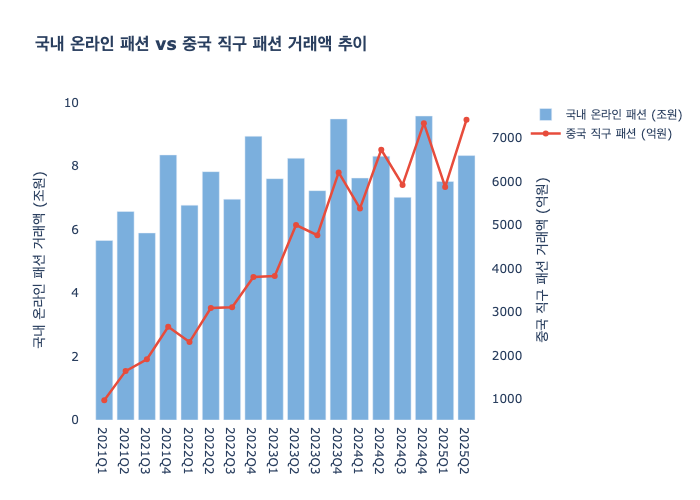

In [13]:
# 국내 vs 중국 직구 패션 거래액 추이 비교
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=Fashion_data['분기'],
        y=Fashion_data['한국_패션'] / 1000000,
        name='국내 온라인 패션 (조원)',
        marker_color='#5B9BD5',
        opacity=0.8
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=Fashion_data['분기'],
        y=Fashion_data['중국_패션'] / 100,
        name='중국 직구 패션 (억원)',
        line=dict(color='#E74C3C', width=2.5),
        mode='lines+markers'
    ),
    secondary_y=True
)

fig.update_layout(
    title='<b>국내 온라인 패션 vs 중국 직구 패션 거래액 추이</b>',
    plot_bgcolor='white',
    height=500
)
fig.update_yaxes(title_text='국내 온라인 패션 거래액 (조원)', secondary_y=False)
fig.update_yaxes(title_text='중국 직구 패션 거래액 (억원)', secondary_y=True)
fig.show(renderer='png')

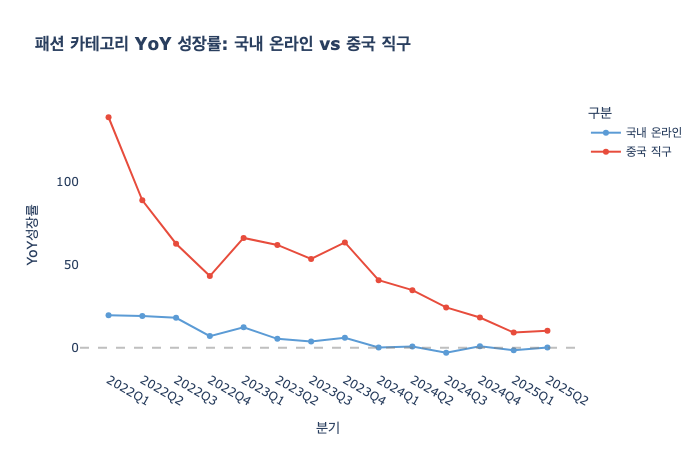


평균 YoY 성장률
  국내 온라인 패션: 6.4%
  중국 직구 패션:   51.1%


In [14]:
# YoY 성장률 비교
Fashion_data = Fashion_data.sort_values('분기').reset_index(drop=True)
Fashion_data['한국_1년전'] = Fashion_data['한국_패션'].shift(4)
Fashion_data['중국_1년전'] = Fashion_data['중국_패션'].shift(4)

Fashion_data['한국_YoY'] = ((Fashion_data['한국_패션'] / Fashion_data['한국_1년전']) - 1) * 100
Fashion_data['중국_YoY'] = ((Fashion_data['중국_패션'] / Fashion_data['중국_1년전']) - 1) * 100
Fashion_data[['한국_YoY', '중국_YoY']] = Fashion_data[['한국_YoY', '중국_YoY']].round(2)

fashion_long = Fashion_data.melt(
    id_vars=['분기'],
    value_vars=['한국_YoY', '중국_YoY'],
    var_name='구분',
    value_name='YoY성장률'
).dropna()

fashion_long['구분'] = fashion_long['구분'].map({'한국_YoY': '국내 온라인', '중국_YoY': '중국 직구'})

fig = px.line(
    fashion_long,
    x='분기',
    y='YoY성장률',
    color='구분',
    color_discrete_map={'국내 온라인': '#5B9BD5', '중국 직구': '#E74C3C'},
    title='<b>패션 카테고리 YoY 성장률: 국내 온라인 vs 중국 직구</b>',
    markers=True,
    height=450
)

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(plot_bgcolor='white')
fig.show(renderer='png')

korea_avg = fashion_long[fashion_long['구분'] == '국내 온라인']['YoY성장률'].mean()
china_avg = fashion_long[fashion_long['구분'] == '중국 직구']['YoY성장률'].mean()
print(f'\n평균 YoY 성장률')
print(f'  국내 온라인 패션: {korea_avg:.1f}%')
print(f'  중국 직구 패션:   {china_avg:.1f}%')

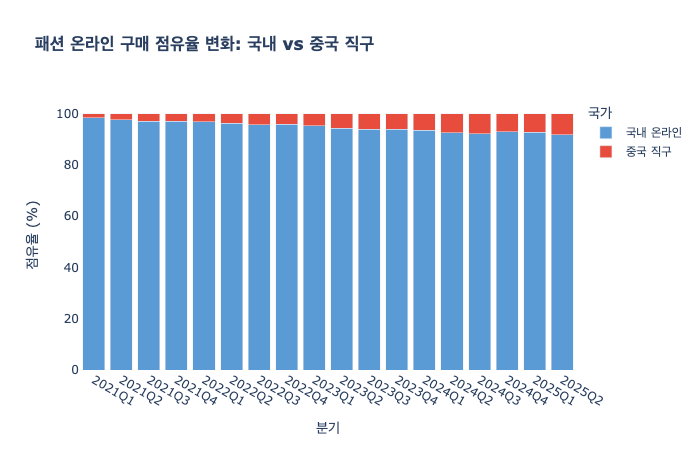


중국 직구 패션 점유율
  초기 (2021Q1): 1.7%
  최근 (2025Q2): 8.2%
  증가: +6.5%p


In [15]:
# 패션 온라인 구매 점유율 변화
Fashion_data['패션_총합'] = Fashion_data['한국_패션'] + Fashion_data['중국_패션']
Fashion_data['한국_점유율'] = (Fashion_data['한국_패션'] / Fashion_data['패션_총합'] * 100).round(1)
Fashion_data['중국_점유율'] = (Fashion_data['중국_패션'] / Fashion_data['패션_총합'] * 100).round(1)

plot_ratio = Fashion_data.melt(
    id_vars=['분기'],
    value_vars=['한국_점유율', '중국_점유율'],
    var_name='국가',
    value_name='점유율 (%)'
).dropna()

plot_ratio['국가'] = plot_ratio['국가'].map({'한국_점유율': '국내 온라인', '중국_점유율': '중국 직구'})

fig = px.bar(
    plot_ratio,
    x='분기',
    y='점유율 (%)',
    color='국가',
    color_discrete_map={'국내 온라인': '#5B9BD5', '중국 직구': '#E74C3C'},
    barmode='stack',
    title='<b>패션 온라인 구매 점유율 변화: 국내 vs 중국 직구</b>',
    height=450
)
fig.update_layout(plot_bgcolor='white')
fig.show(renderer='png')

valid = Fashion_data.dropna(subset=['중국_점유율'])
first_china_share = valid['중국_점유율'].iloc[0]
last_china_share  = valid['중국_점유율'].iloc[-1]
print(f'\n중국 직구 패션 점유율')
print(f'  초기 ({valid["분기"].iloc[0]}): {first_china_share:.1f}%')
print(f'  최근 ({valid["분기"].iloc[-1]}): {last_china_share:.1f}%')
print(f'  증가: +{last_china_share - first_china_share:.1f}%p')

---

## 5.1 패션 판매 채널별 실질 성장 인덱스 비교

국내 온라인, 중국 직구, 백화점(오프라인) 세 채널의 패션 거래 성장 인덱스를 2021Q1 기준으로 비교한다.  
백화점 패션 카테고리는 **23년 Q1까지 성장하다가 Q2부터 매출이 감소세로 전환**되었으며,  
이는 테무 한국 론칭(23.07)·알리익스프레스 사업 확장 시점과 정확히 일치한다.

> **데이터 출처**  
> - 국내 온라인·중국 직구: KOSIS 온라인쇼핑동향조사 (위 분석 동일 데이터)  
> - 백화점: KOSIS 도소매서비스_주요유통업체매출동향조사_백화점 매출 동향(품목별)  
>   (여성정장·여성캐주얼·남성의류 YoY 평균 성장률 기반 인덱스 재구성)


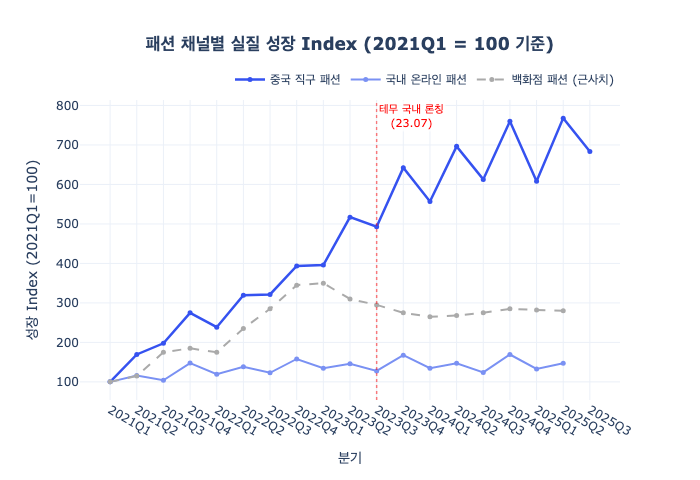

백화점 패션 인덱스 최고점: 2023Q1 (350)
→ 23Q2부터 백화점 패션 감소세 → 테무 국내 론칭·알리익스프레스 확장 시점과 일치
→ 전체 패션 수요는 유지되며 구매 채널이 백화점 → C-commerce로 이동하는 구조적 변화 확인


In [16]:
# ── 패션 채널별 실질 성장 인덱스 비교 ──────────────────────────────────
# 중국 직구: df_indexed (Cell 13에서 2021Q1=100 기준으로 계산됨)
# 국내 온라인: Fashion_data['한국_패션'] (Cell 17)
# 백화점: PPT 기반 근사치 (KOSIS 도소매서비스_백화점매출동향 재구성)

import plotly.graph_objects as go
import pandas as pd

# ── 중국 직구 패션 인덱스 (df_indexed 재사용) ───────────────────────────
df_china_idx = df_indexed[['분기', '의류 및 패션 관련 상품']].copy()
df_china_idx = df_china_idx.rename(columns={'의류 및 패션 관련 상품': '중국_직구_인덱스'})
df_china_idx['중국_직구_인덱스'] = pd.to_numeric(df_china_idx['중국_직구_인덱스'], errors='coerce')

# ── 국내 온라인 패션 인덱스 (2021Q1=100 기준으로 재정규화) ─────────────────
base_korea = Fashion_data[Fashion_data['분기'] == '2021Q1']['한국_패션'].values[0]
Fashion_data_idx = Fashion_data[['분기', '한국_패션']].copy()
Fashion_data_idx['국내_온라인_인덱스'] = (
    Fashion_data_idx['한국_패션'] / base_korea * 100
).round(1)

# ── 백화점 패션 인덱스 (PPT 기반 근사치) ────────────────────────────────
# 출처: KOSIS 도소매서비스_주요유통업체매출동향조사_백화점 매출동향(품목별)
# 여성정장·여성캐주얼·남성의류 YoY 평균 성장률 기반 재구성
dept_index = {
    '2021Q1': 100,  '2021Q2': 115,  '2021Q3': 175,  '2021Q4': 185,
    '2022Q1': 175,  '2022Q2': 235,  '2022Q3': 285,  '2022Q4': 345,
    '2023Q1': 350,  '2023Q2': 310,  '2023Q3': 295,  '2023Q4': 275,
    '2024Q1': 265,  '2024Q2': 268,  '2024Q3': 275,  '2024Q4': 285,
    '2025Q1': 282,  '2025Q2': 280,
}
df_dept = pd.DataFrame({'분기': list(dept_index.keys()),
                         '백화점_인덱스': list(dept_index.values())})

# ── 병합 ─────────────────────────────────────────────────────────────
df_merge = df_china_idx.merge(
    Fashion_data_idx[['분기', '국내_온라인_인덱스']], on='분기', how='outer'
).merge(df_dept, on='분기', how='outer').sort_values('분기').reset_index(drop=True)

# ── 시각화 ───────────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_merge['분기'], y=df_merge['중국_직구_인덱스'],
    name='중국 직구 패션', mode='lines+markers',
    line=dict(color='#3552F0', width=2.5), marker=dict(size=5)
))
fig.add_trace(go.Scatter(
    x=df_merge['분기'], y=df_merge['국내_온라인_인덱스'],
    name='국내 온라인 패션', mode='lines+markers',
    line=dict(color='#7A91F3', width=2), marker=dict(size=5)
))
fig.add_trace(go.Scatter(
    x=df_merge['분기'], y=df_merge['백화점_인덱스'],
    name='백화점 패션 (근사치)', mode='lines+markers',
    line=dict(color='#AAAAAA', width=2, dash='dash'), marker=dict(size=5)
))

# 테무 한국 론칭 시점 (categorical x-axis: add_shape + add_annotation 사용)
fig.add_shape(
    type='line', xref='x', yref='paper',
    x0='2023Q3', y0=0, x1='2023Q3', y1=1,
    line=dict(color='red', width=1.5, dash='dot'),
    opacity=0.5
)
fig.add_annotation(
    x='2023Q3', y=1, yref='paper',
    text='테무 국내 론칭<br>(23.07)',
    showarrow=False,
    xanchor='left',
    font=dict(color='red', size=11),
    bgcolor='rgba(255,255,255,0.7)'
)

fig.update_layout(
    title='<b>패션 채널별 실질 성장 Index (2021Q1 = 100 기준)</b>',
    xaxis_title='분기',
    yaxis_title='성장 Index (2021Q1=100)',
    template='plotly_white',
    height=480,
    title_x=0.5, title_xanchor='center',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show(renderer='png')

peak_q = df_dept.loc[df_dept['백화점_인덱스'].idxmax(), '분기']
peak_v = df_dept['백화점_인덱스'].max()
print(f'백화점 패션 인덱스 최고점: {peak_q} ({peak_v})')
print('→ 23Q2부터 백화점 패션 감소세 → 테무 국내 론칭·알리익스프레스 확장 시점과 일치')
print('→ 전체 패션 수요는 유지되며 구매 채널이 백화점 → C-commerce로 이동하는 구조적 변화 확인')


---

## 6. 구조적 요인 분석

중국 C-commerce의 패션 카테고리 급성장을 설명하는 **3가지 구조적 요인**을 정리한다.

---

### 요인 1. 가격 구조

- 테무 의류 베스트셀러 10만원 이하 기준, **4만원 이하 상품이 92% 압도적 비중** (판매량 약 900만개 기준)
- 한국 의류 수출 단가 >> 중국 의류 수입 단가 → 중간유통 마진 제거로 가격 경쟁력 확보
- 온라인쇼핑 편의성, 계절성·주기성·충동심리, 다양한 트렌드 상품 제공이 복합 작용

---

### 요인 2. 관세 구조

| 품목 | 관세(%) | 부가세(%) |
|------|--------|----------|
| 의류 | 13 | 10 |
| 신발 | 13 | 10 |
| 가방(200만원 이하) | 8 | 10 |

- 중국 해외직구 **면세 기준: 1,080위안 이하** (환율 208.65원 기준 약 **225,000원**)
- 테무·알리의 저가 패션 상품 대부분이 면세 기준 이내 → 실질 관세 부담 없음

---

### 요인 3. 소비자 심리 (CSI)

- 2021년 이후 패션 카테고리 소비자지출전망(CSI)은 **항상 기준치 100 이상** 유지
- 의류는 식품·생활용품 대비 브랜드 충성도가 낮아 가성비 채널 이동이 용이
- **"같은 예산에서 더 쓰고 가성비 있는 채널로 이동"** 심리 → C-commerce 유입 가속

---

### 요인 4. 마케팅·광고 노출 (YouTube 스크래핑)

- 테무·알리 검색 시 YouTube에서 노출되는 제목을 Selenium으로 스크래핑
- 실질 키워드('테무', '태무깡') 위주 수집 → 카테고리별 언급량 산출
- **결과:** 의류·패션 관련 상품 약 **50건**으로 압도적 1위 > 생활가전용품 34건 > 화장품 14건

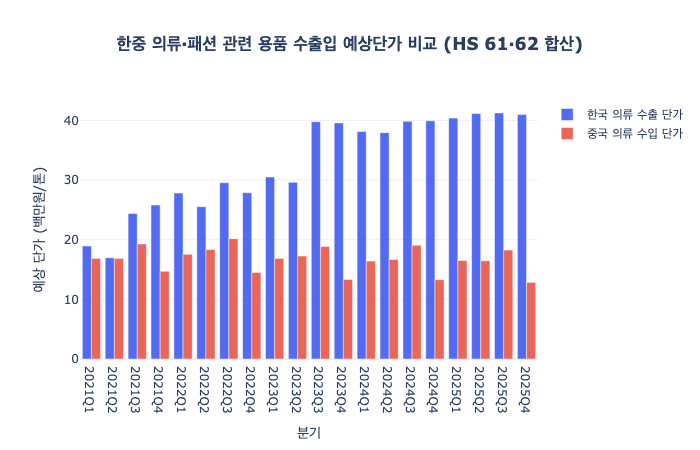

한국 의류 수출 단가 / 중국 의류 수입 단가 평균 배율: 2.01x
→ 한국 의류는 중국 대비 평균 2.0배 높은 단가
→ C-commerce 직구 시 중간 유통마진 제거 → 소비자 실감 가격 차이 더욱 커짐


In [17]:
# ── 요인 1: 가격 구조 — 한중 의류·패션 수출입 단가 비교 ──────────────────
import plotly.graph_objects as go
import pandas as pd

# 수출입 데이터 로드 (HS 61, 62 합산)
df_trade = pd.read_excel('패션의류_수출입실적.xlsx', sheet_name='총합')
df_main = df_trade[df_trade['HS코드'].isin([61, 62])].copy()

# 날짜 파싱 & 분기 변환
df_main['날짜'] = pd.to_datetime(df_main['기간'].astype(str), format='%Y.%m')
df_main['분기'] = df_main['날짜'].dt.to_period('Q').astype(str)

# 분기별 HS61+HS62 합산 단가 계산
df_q = df_main.groupby('분기').agg({'수출 금액': 'sum', '수출 중량': 'sum',
                                    '수입 금액': 'sum', '수입 중량': 'sum'}).reset_index()
df_q['한국_단가'] = df_q['수출 금액'] / df_q['수출 중량']   # 단위: 백만원/톤
df_q['중국_단가'] = df_q['수입 금액'] / df_q['수입 중량']
df_q = df_q[df_q['분기'] >= '2021Q1'].sort_values('분기')

fig = go.Figure()
fig.add_trace(go.Bar(x=df_q['분기'], y=df_q['한국_단가'],
                     name='한국 의류 수출 단가', marker_color='#3552F0', opacity=0.85))
fig.add_trace(go.Bar(x=df_q['분기'], y=df_q['중국_단가'],
                     name='중국 의류 수입 단가', marker_color='#E74C3C', opacity=0.85))

fig.update_layout(
    title='<b>한중 의류·패션 관련 용품 수출입 예상단가 비교 (HS 61·62 합산)</b>',
    xaxis_title='분기', yaxis_title='예상 단가 (백만원/톤)',
    barmode='group', template='plotly_white',
    height=450, title_x=0.5, title_xanchor='center'
)
fig.show(renderer='png')

avg_ratio = (df_q['한국_단가'] / df_q['중국_단가']).mean()
print(f'한국 의류 수출 단가 / 중국 의류 수입 단가 평균 배율: {avg_ratio:.2f}x')
print(f'→ 한국 의류는 중국 대비 평균 {avg_ratio:.1f}배 높은 단가')
print('→ C-commerce 직구 시 중간 유통마진 제거 → 소비자 실감 가격 차이 더욱 커짐')


---

### 요인 4: 마케팅·광고 노출 — 유튜브 스크래핑

테무·알리 관련 유튜브 영상 제목을 **Selenium**으로 수집해 카테고리별 광고 노출 집중도를 파악한다.

**수집 방법**
- 검색 키워드: `'테무깡'`, `'알리깡'`, `'테무'`, `'알리익스프레스'`, `'알리'` (5개)
- 키워드당 최대 100개 영상, 페이지 스크롤 20회로 충분한 영상 확보
- 수집 항목: 영상 제목, 설명, 링크
- 중복 링크 제거 후 분석 사용

> 수집 결과는 `youtube_data.csv`에 저장되며, 이미 파일이 존재하면 스크래핑을 스킵합니다.

In [1]:
# ── 유튜브 영상 제목 수집 (Selenium) ──────────────────────────────────────
# ※ youtube_data.csv 가 이미 존재하면 이 셀은 스킵됩니다.
import os

if not os.path.exists('youtube_data.csv'):
    from selenium import webdriver
    from selenium.webdriver.chrome.service import Service
    from selenium.webdriver.chrome.options import Options
    from selenium.webdriver.common.by import By
    from selenium.webdriver.common.keys import Keys
    from webdriver_manager.chrome import ChromeDriverManager
    import time
    import pandas as pd

    options = Options()
    options.add_argument("--disable-blink-features=AutomationControlled")
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

    search_keywords = ['테무깡', '알리깡', '테무', '알리익스프레스', '알리']
    final_data = []

    try:
        for kw in search_keywords:
            print(f"'{kw}' 검색 결과 수집 중...")
            url = f"https://www.youtube.com/results?search_query={kw}"
            driver.get(url)
            time.sleep(3)

            # 스크롤로 충분한 영상 확보 (20회)
            for _ in range(20):
                driver.find_element(By.TAG_NAME, 'body').send_keys(Keys.END)
                time.sleep(1.5)

            video_containers = driver.find_elements(By.XPATH, '//*[@id="dismissible"]')
            count = 0
            for container in video_containers:
                try:
                    title_element = container.find_element(By.ID, "video-title")
                    title = title_element.get_attribute('title') or title_element.text
                    link  = title_element.get_attribute('href')
                    try:
                        description = container.find_element(By.ID, "description-text").text
                    except:
                        description = ""
                    if title and link and "/watch" in link:
                        final_data.append({
                            '검색어': kw,
                            '영상제목': title,
                            '설명': description.replace('\n', ' '),
                            '링크': link
                        })
                        count += 1
                    if count >= 100:
                        break
                except:
                    continue
            print(f"  {kw} 수집 완료 ({count}개)")
    finally:
        driver.quit()

    if final_data:
        df_raw = pd.DataFrame(final_data)
        df_raw.to_csv('youtube_data.csv', index=False, encoding='utf-8-sig')
        print(f"\n총 {len(df_raw)}건 저장 완료 → youtube_data.csv")
else:
    df_raw = pd.read_csv('youtube_data.csv')
    print(f"youtube_data.csv 존재 — 스크래핑 스킵 (총 {len(df_raw)}건 로드)")

🚀 '테무깡' 검색 결과 수집 중...
✅ 테무깡 수집 완료 (100개)
🚀 '알리깡' 검색 결과 수집 중...
✅ 알리깡 수집 완료 (100개)
🚀 '테무' 검색 결과 수집 중...
✅ 테무 수집 완료 (100개)
🚀 '알리익스프레스' 검색 결과 수집 중...
✅ 알리익스프레스 수집 완료 (100개)
🚀 '알리' 검색 결과 수집 중...
✅ 알리 수집 완료 (100개)

✨ 총 500건 저장 완료 (설명 포함)!


In [18]:
# ── 중복 링크 제거 → youtube_titles.csv 저장 ──────────────────────────────
# 동일 영상이 여러 키워드로 수집될 수 있으므로 링크 기준 중복 제거
import os
import pandas as pd

if not os.path.exists('youtube_titles.csv'):
    df_raw = pd.read_csv('youtube_data.csv')
    df_dedup = df_raw.drop_duplicates(subset=['링크'], keep='first').reset_index(drop=True)
    df_dedup.to_csv('youtube_titles.csv', index=False, encoding='utf-8-sig')
    print(f"중복 제거: {len(df_raw)}건 → {len(df_dedup)}건 → youtube_titles.csv 저장")
else:
    df_dedup = pd.read_csv('youtube_titles.csv')
    print(f"youtube_titles.csv 로드 완료: {len(df_dedup)}건")

df_dedup.head(3)

youtube_titles.csv 로드 완료: 320건


,검색어,영상제목,링크
0,테무깡,25만원어치 테무깡 🛒🎄•• 귀엽고 실용적인 템만 쏙쏙 골라옴,https://www.youtube.com/watch?v=ugK_z7q1V3Y&pp...
1,테무깡,테무 그거 어떻게 끊는 건데;; (겨울 칩거템 테무깡📦☃️),https://www.youtube.com/watch?v=0D3I-8kfmig&pp...
2,테무깡,꿀템 발굴러의 충격적인 첫 테무깡💰 편견 박살내버린 가성비 꿀템들 알랴드림!,https://www.youtube.com/watch?v=KfOFZb0ZEdA&pp...


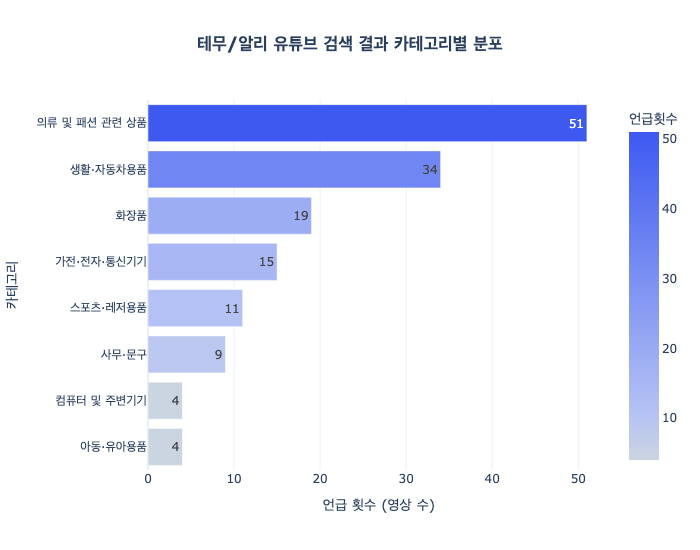


1위: 의류 및 패션 관련 상품 — 51건
→ YouTube 광고·마케팅이 의류·패션에 집중됨을 실증


In [19]:
# ── 요인 4: 마케팅·광고 노출 — 유튜브 카테고리별 분포 ────────────────────
import pandas as pd
import plotly.express as px

# 유튜브 스크래핑 데이터 로드 (중복 제거된 버전)
df_yt = pd.read_csv('youtube_titles.csv')

# 카테고리 분류 키워드 (Youtube_title.ipynb 동일 기준)
category_keywords = {
    '의류 및 패션 관련 상품': ['옷', '패션', '가방', '티셔츠', '바지', '원피스', '신발', '액세서리',
                          '귀걸이', '코디', '룩북', '팬츠', '모자', '양말', '패션하울', '잠옷',
                          '지갑', '아우터', '사이즈'],
    '생활·자동차용품':       ['생활용품', '주방', '정리', '자동차', '세제', '청소', '욕실', '인테리어',
                          '수납', '담요', '의자', '데스크', '차량', '집꾸', '방꾸', '리빙', '그릴'],
    '화장품':               ['화장품', '메이크업', '뷰티', '스킨', '로션', '틴트', '코스메틱',
                          '브러쉬', '립', '블러셔', '라이너', '네일', '퍼프', '파데', '파운데이션',
                          '쿠션', '속눈썹'],
    '가전·전자·통신기기':    ['전자', '전자기기', '충전기', '이어폰', '가전', '조명', '키보드',
                          '마우스', '스피커', '케이스', '폰', '무선이어폰', '블루투스', '거치대'],
    '스포츠·레저용품':       ['운동', '캠핑', '등산', '헬스', '낚시', '골프', '자전거', '스포츠',
                          '러닝', '무릎', '보호대', '볼', '마사지', '보드'],
    '사무·문구':            ['문구', '스티커', '다꾸', '펜', '노트', '사무', '필기구', '플래너',
                          '마우스패드', '계산기', '메모', '가위', '다이어리'],
    '아동·유아용품':         ['아기', '유아', '장난감', '인형', '키즈', '육아', '레고', '퍼즐',
                          '어린이', '베이비'],
    '컴퓨터 및 주변기기':    ['컴퓨터', '노트북', '모니터', 'USB', '허브', '태블릿', '외장', '키캡'],
}

cat_results = []
for cat, keywords in category_keywords.items():
    count = sum(1 for title in df_yt['영상제목']
                if isinstance(title, str) and any(kw in title for kw in keywords))
    cat_results.append({'카테고리': cat, '언급횟수': count})

df_cat = pd.DataFrame(cat_results).sort_values('언급횟수', ascending=True)

color_scale = ['#CBD5E1', '#B5C2F4', '#A1B1F3', '#8D9FF2', '#798EF2',
               '#657CF1', '#516BF1', '#3D59F0']

fig = px.bar(
    df_cat, x='언급횟수', y='카테고리', orientation='h',
    title='<b>테무/알리 유튜브 검색 결과 카테고리별 분포</b>',
    text='언급횟수',
    color='언급횟수',
    color_continuous_scale=color_scale,
    template='plotly_white'
)
fig.update_layout(
    xaxis_title='언급 횟수 (영상 수)', yaxis_title='카테고리',
    font=dict(size=12), height=550,
    title_x=0.5, title_xanchor='center'
)
fig.show(renderer='png')

top_cat = df_cat.sort_values('언급횟수', ascending=False).iloc[0]
print(f'\n1위: {top_cat["카테고리"]} — {top_cat["언급횟수"]}건')
print('→ YouTube 광고·마케팅이 의류·패션에 집중됨을 실증')


---

## 7. 결론 및 시사점

### 📌 핵심 결론

중국 C-commerce 패션 카테고리의 급성장은 단순한 가격 경쟁력을 넘어  
**'가격·관세·소비자 심리'라는 구조적 요인**에 **SNS·유튜브 광고 노출의 집중**이 결합된 결과다.

```
[소비자 선택 단계 (주요 요인)]
  ① 중간유통 마진 제거 → 저렴한 가격
  ② 면세 혜택 → 실질 관세 부담 최소화
  ③ 소비자 심리 → 가성비 채널로의 자발적 이동
  ④ 다양한 트렌드 상품 + 계절성·충동 구매

[광고 노출 단계 (보조 요인)]
  ⑤ 패션·의류 분야 공격적 디지털 마케팅
  → YouTube 카테고리별 노출에서 의류·패션 압도적 1위
```

> **분석 한계:** 테무·알리 내부 데이터 미확보로 패션 카테고리 구매 전환율 직접 검증 불가

### 💡 시사점

국내 이커머스는 가격 경쟁만으로 대응하기 어려운 구조다.  
→ **배송 안정성·CS 신뢰·품질 관리** 등 차별적 전략이 필요하다.